# **FRAMEWORK V7 - C15 EVALUACIÓN DE MODELOS**

Este notebook evalúa y reproduce de forma independiente los modelos publicados por C14.

**Principio de diseño:** C15 no vuelve a ajustar transformadores ni modelos. Descarga los tensores RAW, el split temporal, el modelo y los scalers generados por C14; aplica los transformadores ya ajustados exclusivamente con entrenamiento y ejecuta la inferencia respetando exactamente la estructura temporal utilizada durante el modelado.

Actualmente soporta de forma automática:

- **Exp01:** clasificación binaria (`nivel_de_riesgo`).
- **Exp04:** regresión (`VolumenUtilDiarioMasa`) con `scaler.pkl` para X y `scaler_y.pkl` para recuperar la salida en unidades originales.


## **M0. Configuración del Experimento de Evaluación**


In [1]:
#==========================================================================================
# SCRIPT 50
# CONFIGURACIÓN DEL EXPERIMENTO DE EVALUACIÓN
#==========================================================================================

# Cambiar únicamente esta variable para evaluar otro experimento publicado por C14.
EXPERIMENTO = "Exp01"   # Opciones actuales: "Exp01", "Exp04"

# Umbral usado por C14 para clasificación binaria.
UMBRAL_CLASIFICACION = 0.50

# Tolerancia para comprobar que el scaler recuperado reproduce tensor_X.npy de C14.
TOLERANCIA_TENSOR = 1e-4

# Base pública del repositorio.
BASE_GITHUB = (
    "https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/"
    "refs/heads/main/DATA/MODELADO/"
)

print()
print("=" * 90)
print("CONFIGURACIÓN DEL EXPERIMENTO")
print("=" * 90)
print()
print(f"Experimento seleccionado : {EXPERIMENTO}")
print(f"Umbral clasificación     : {UMBRAL_CLASIFICACION}")
print("Fuente                    : artefactos publicados por C14 en GitHub")



CONFIGURACIÓN DEL EXPERIMENTO

Experimento seleccionado : Exp01
Umbral clasificación     : 0.5
Fuente                    : artefactos publicados por C14 en GitHub


## **M1. Librerías, Utilidades y Directorios**


In [2]:
#==========================================================================================
# SCRIPT 51
# LIBRERÍAS, UTILIDADES Y DIRECTORIOS
#==========================================================================================

import os
import re
import json
import shutil
import hashlib
import unicodedata
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

CARPETA_PREDICCIONES = f"predicciones/{EXPERIMENTO}"
os.makedirs(CARPETA_PREDICCIONES, exist_ok=True)


def normalizar_parametro(texto):
    texto = unicodedata.normalize("NFKD", str(texto))
    texto = "".join(
        caracter for caracter in texto
        if not unicodedata.combining(caracter)
    )
    texto = texto.lower().strip()
    texto = re.sub(r"\s+", " ", texto)
    return texto


def obtener_parametro(df, nombres, default=None, requerido=True):
    if isinstance(nombres, str):
        nombres = [nombres]

    if not {"Parametro", "Valor"}.issubset(df.columns):
        raise ValueError("La metadata debe contener las columnas 'Parametro' y 'Valor'.")

    mapa = {
        normalizar_parametro(parametro): valor
        for parametro, valor in zip(df["Parametro"], df["Valor"])
    }

    for nombre in nombres:
        clave = normalizar_parametro(nombre)
        if clave in mapa and pd.notna(mapa[clave]):
            valor = mapa[clave]
            if isinstance(valor, str) and valor.strip() == "":
                continue
            return valor

    if requerido:
        raise KeyError(
            "No se encontró ninguno de estos parámetros: "
            + ", ".join(nombres)
        )

    return default


def descargar_archivo(url, ruta_local, obligatorio=True):
    try:
        respuesta = requests.get(url, timeout=180)
    except requests.RequestException as exc:
        if obligatorio:
            raise RuntimeError(f"No fue posible descargar {url}: {exc}") from exc
        return None

    if respuesta.status_code != 200:
        if obligatorio:
            raise RuntimeError(
                f"Descarga fallida ({respuesta.status_code}) para: {url}"
            )
        return None

    with open(ruta_local, "wb") as archivo:
        archivo.write(respuesta.content)

    if os.path.getsize(ruta_local) == 0:
        if obligatorio:
            raise IOError(f"El archivo descargado está vacío: {ruta_local}")
        return None

    return ruta_local


def sha256_archivo(ruta):
    hash_obj = hashlib.sha256()
    with open(ruta, "rb") as archivo:
        for bloque in iter(lambda: archivo.read(1024 * 1024), b""):
            hash_obj.update(bloque)
    return hash_obj.hexdigest()


def es_clasificacion(tipo):
    return normalizar_parametro(tipo).startswith("clas")


def es_regresion(tipo):
    return normalizar_parametro(tipo).startswith("reg")


print()
print("=" * 90)
print("LIBRERÍAS Y DIRECTORIOS")
print("=" * 90)
print()
print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)
print("Salida     :", CARPETA_PREDICCIONES)



LIBRERÍAS Y DIRECTORIOS

TensorFlow : 2.20.0
NumPy      : 2.0.2
Pandas     : 2.2.2
Salida     : predicciones/Exp01


## **M2. Carga Automática de Metadata de C14**


In [3]:
#==========================================================================================
# SCRIPT 52
# DESCARGA DE METADATA Y RECUPERACIÓN DE CONFIGURACIÓN DE C14
#==========================================================================================

BASE_MODELOS = BASE_GITHUB + f"Modelos/{EXPERIMENTO}/"
BASE_TENSORES = BASE_GITHUB + f"Tensores/{EXPERIMENTO}/"
BASE_DIAGNOSTICOS = BASE_GITHUB + f"Diagnosticos/{EXPERIMENTO}/"
BASE_METRICAS = BASE_GITHUB + f"Metricas/{EXPERIMENTO}/"

RUTA_METADATA_TENSOR = "metadata_tensor.csv"
RUTA_METADATA_MODELO = "metadata_modelo.csv"
RUTA_METADATA_SPLIT = "metadata_split.csv"
RUTA_DIAGNOSTICO_C14 = f"diagnostico_modelo_{EXPERIMENTO}.csv"

descargar_archivo(
    BASE_TENSORES + "metadata_tensor.csv",
    RUTA_METADATA_TENSOR
)

descargar_archivo(
    BASE_MODELOS + "metadata_modelo.csv",
    RUTA_METADATA_MODELO
)

descargar_archivo(
    BASE_TENSORES + "metadata_split.csv",
    RUTA_METADATA_SPLIT
)

descargar_archivo(
    BASE_DIAGNOSTICOS + f"diagnostico_modelo_{EXPERIMENTO}.csv",
    RUTA_DIAGNOSTICO_C14
)

metadata_tensor = pd.read_csv(
    RUTA_METADATA_TENSOR,
    encoding="utf-8-sig"
)

metadata_modelo = pd.read_csv(
    RUTA_METADATA_MODELO,
    encoding="utf-8-sig"
)

metadata_split = pd.read_csv(
    RUTA_METADATA_SPLIT,
    encoding="utf-8-sig"
)

diagnostico_c14 = pd.read_csv(
    RUTA_DIAGNOSTICO_C14,
    encoding="utf-8-sig"
)

DOMINIO = str(obtener_parametro(metadata_tensor, "Dominio"))
TIPO_PROBLEMA = str(obtener_parametro(metadata_tensor, ["Tipo Problema", "Tipo de Problema"]))
TIPO_MODELO = str(obtener_parametro(metadata_tensor, "Modelo", default="LSTM", requerido=False))
VARIABLE_OBJETIVO = str(obtener_parametro(metadata_tensor, "Variable Objetivo"))
VARIABLE_OBJETIVO_CIENTIFICO = str(
    obtener_parametro(
        metadata_tensor,
        ["Variable Objetivo Cientifico", "Variable Objetivo Científico"],
        default=VARIABLE_OBJETIVO,
        requerido=False
    )
)
VENTANA = int(float(obtener_parametro(metadata_tensor, "Ventana")))
HORIZONTE = int(float(obtener_parametro(metadata_tensor, "Horizonte")))
NUM_VARIABLES = int(float(obtener_parametro(metadata_tensor, "Variables Predictoras")))
NUM_SECUENCIAS = int(float(obtener_parametro(metadata_tensor, "Numero Secuencias")))
METODO_TRANSFORMACION = str(
    obtener_parametro(
        metadata_tensor,
        ["Metodo Transformacion", "Método de Transformación"],
        default="Ninguno",
        requerido=False
    )
)

VARIABLES_MODELO = [
    variable.strip()
    for variable in str(
        obtener_parametro(metadata_tensor, "Variables Modelo")
    ).split(";")
    if variable.strip()
]

ARCHIVO_SCALER_X = str(
    obtener_parametro(
        metadata_modelo,
        "Scaler",
        default="scaler.pkl",
        requerido=False
    )
).strip()

TRANSFORMACION_OBJETIVO = str(
    obtener_parametro(
        metadata_modelo,
        "Transformacion Objetivo",
        default="No aplica",
        requerido=False
    )
)

ARCHIVO_SCALER_Y = str(
    obtener_parametro(
        metadata_modelo,
        "Scaler Objetivo",
        default="",
        requerido=False
    )
).strip()

NOMBRE_MODELO = f"modelo_{EXPERIMENTO}_{VARIABLE_OBJETIVO}.keras"

fila_estado = diagnostico_c14.loc[
    diagnostico_c14["Indicador"].astype(str).map(normalizar_parametro)
    == normalizar_parametro("Estado General"),
    "Valor"
]

ESTADO_C14 = (
    str(fila_estado.iloc[0])
    if len(fila_estado) > 0
    else "NO REGISTRADO"
)

print()
print("=" * 90)
print("CONFIGURACIÓN RECUPERADA DE C14")
print("=" * 90)
print()
print(f"Experimento              : {EXPERIMENTO}")
print(f"Dominio                  : {DOMINIO}")
print(f"Tipo de problema         : {TIPO_PROBLEMA}")
print(f"Objetivo modelo          : {VARIABLE_OBJETIVO}")
print(f"Objetivo científico      : {VARIABLE_OBJETIVO_CIENTIFICO}")
print(f"Modelo                   : {TIPO_MODELO}")
print(f"Ventana / Horizonte      : {VENTANA} / {HORIZONTE}")
print(f"Variables predictoras    : {NUM_VARIABLES}")
print(f"Secuencias C14           : {NUM_SECUENCIAS}")
print(f"Transformación X         : {METODO_TRANSFORMACION}")
print(f"Transformación y         : {TRANSFORMACION_OBJETIVO}")
print(f"Estado reportado C14     : {ESTADO_C14}")
print()
print("Variables del modelo:")
for variable in VARIABLES_MODELO:
    print("-", variable)



CONFIGURACIÓN RECUPERADA DE C14

Experimento              : Exp01
Dominio                  : Gestión Hídrica
Tipo de problema         : Clasificación
Objetivo modelo          : nivel_de_riesgo
Objetivo científico      : irca
Modelo                   : LSTM
Ventana / Horizonte      : 12 / 1
Variables predictoras    : 8
Secuencias C14           : 480
Transformación X         : RobustScaler
Transformación y         : No aplica
Estado reportado C14     : EVALUACION LIMITADA - TEST CON UNA SOLA CLASE

Variables del modelo:
- ONI
- PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS
- Precipitacion_mm
- Radiacion_Solar
- Humedad_Relativa
- Temp_Min_C
- Mes
- Velocidad_Viento


## **M3. Descarga y Carga del Modelo, Tensores y Scalers**


In [4]:
#==========================================================================================
# SCRIPT 53
# DESCARGA DE ARTEFACTOS BINARIOS PUBLICADOS POR C14
#==========================================================================================

ARCHIVOS_TENSOR = {
    "tensor_X": "tensor_X.npy",
    "tensor_X_raw": "tensor_X_raw.npy",
    "tensor_y": "tensor_y.npy"
}

for nombre in ARCHIVOS_TENSOR.values():
    descargar_archivo(
        BASE_TENSORES + nombre,
        nombre
    )

RUTA_MODELO_LOCAL = "modelo.keras"
descargar_archivo(
    BASE_MODELOS + NOMBRE_MODELO,
    RUTA_MODELO_LOCAL
)

RUTA_SCALER_X_LOCAL = None
if ARCHIVO_SCALER_X:
    RUTA_SCALER_X_LOCAL = "scaler.pkl"
    descargar_archivo(
        BASE_MODELOS + ARCHIVO_SCALER_X,
        RUTA_SCALER_X_LOCAL
    )

RUTA_SCALER_Y_LOCAL = None
if ARCHIVO_SCALER_Y:
    RUTA_SCALER_Y_LOCAL = "scaler_y.pkl"
    descargar_archivo(
        BASE_MODELOS + ARCHIVO_SCALER_Y,
        RUTA_SCALER_Y_LOCAL
    )

# Archivo de prueba de C14: opcional, se usa después para una validación cruzada.
RUTA_PREDICCIONES_C14 = f"predicciones_prueba_{EXPERIMENTO}.csv"
descargar_archivo(
    BASE_METRICAS + RUTA_PREDICCIONES_C14,
    RUTA_PREDICCIONES_C14,
    obligatorio=False
)

print()
print("=" * 90)
print("ARTEFACTOS C14 DESCARGADOS")
print("=" * 90)
print()
print("- tensor_X.npy")
print("- tensor_X_raw.npy")
print("- tensor_y.npy")
print(f"- {NOMBRE_MODELO}")
print(f"- {ARCHIVO_SCALER_X if ARCHIVO_SCALER_X else 'sin scaler X'}")
print(f"- {ARCHIVO_SCALER_Y if ARCHIVO_SCALER_Y else 'sin scaler y'}")



ARTEFACTOS C14 DESCARGADOS

- tensor_X.npy
- tensor_X_raw.npy
- tensor_y.npy
- modelo_Exp01_nivel_de_riesgo.keras
- scaler.pkl
- sin scaler y


In [5]:
#==========================================================================================
# SCRIPT 54
# CARGA DE ARTEFACTOS
#==========================================================================================

X_publicado = np.load(
    ARCHIVOS_TENSOR["tensor_X"],
    allow_pickle=False
)

X_raw = np.load(
    ARCHIVOS_TENSOR["tensor_X_raw"],
    allow_pickle=False
)

y = np.load(
    ARCHIVOS_TENSOR["tensor_y"],
    allow_pickle=False
)

# C15 solo necesita inferencia; compile=False evita depender de la configuración
# de optimización/pérdida utilizada durante C14.
modelo = keras.models.load_model(
    RUTA_MODELO_LOCAL,
    compile=False
)

scaler = (
    joblib.load(RUTA_SCALER_X_LOCAL)
    if RUTA_SCALER_X_LOCAL
    else None
)

scaler_y = (
    joblib.load(RUTA_SCALER_Y_LOCAL)
    if RUTA_SCALER_Y_LOCAL
    else None
)

for columna in ["Fecha_Inicio", "Fecha_Fin", "Fecha_Objetivo"]:
    if columna in metadata_split.columns:
        metadata_split[columna] = pd.to_datetime(
            metadata_split[columna],
            errors="raise"
        )

if "Indice_Secuencia" not in metadata_split.columns:
    raise ValueError(
        "metadata_split.csv no contiene Indice_Secuencia. "
        "Use los artefactos actualizados de C14."
    )

metadata_split["Indice_Secuencia"] = (
    metadata_split["Indice_Secuencia"].astype(int)
)

metadata_split = (
    metadata_split
    .sort_values("Indice_Secuencia")
    .reset_index(drop=True)
)

print()
print("=" * 90)
print("ARTEFACTOS CARGADOS")
print("=" * 90)
print()
print(f"tensor_X publicado : {X_publicado.shape}")
print(f"tensor_X RAW       : {X_raw.shape}")
print(f"tensor_y           : {y.shape}")
print(f"metadata_split     : {metadata_split.shape}")
print(f"Modelo input       : {modelo.input_shape}")
print(f"Modelo output      : {modelo.output_shape}")
print(f"Scaler X           : {type(scaler).__name__ if scaler is not None else 'No aplica'}")
print(f"Scaler y           : {type(scaler_y).__name__ if scaler_y is not None else 'No aplica'}")



ARTEFACTOS CARGADOS

tensor_X publicado : (480, 12, 8)
tensor_X RAW       : (480, 12, 8)
tensor_y           : (480,)
metadata_split     : (480, 6)
Modelo input       : (None, 12, 8)
Modelo output      : (None, 1)
Scaler X           : RobustScaler
Scaler y           : No aplica


## **M4. Validación de Integridad y Reproducción del Escalamiento**


In [6]:
#==========================================================================================
# SCRIPT 55
# VALIDACIÓN INTEGRAL DE ARTEFACTOS Y REPRODUCCIÓN DE tensor_X.npy
#==========================================================================================


def tensor_a_2d(tensor):
    return tensor.reshape(-1, tensor.shape[2])


def transformar_tensor_3d(tensor, transformador):
    if transformador is None:
        return tensor.astype(np.float32)

    forma = tensor.shape
    transformado = transformador.transform(
        tensor_a_2d(tensor)
    )
    return transformado.reshape(forma).astype(np.float32)


X_pred = transformar_tensor_3d(
    X_raw,
    scaler
)

DIFERENCIA_MAX_TENSOR = float(
    np.max(
        np.abs(
            X_pred.astype(np.float64)
            - X_publicado.astype(np.float64)
        )
    )
)

indices_esperados = np.arange(len(metadata_split))

input_shape_modelo = modelo.input_shape
if isinstance(input_shape_modelo, list):
    input_shape_modelo = input_shape_modelo[0]

controles_integridad = {
    "X_raw_es_3D": X_raw.ndim == 3,
    "X_publicado_es_3D": X_publicado.ndim == 3,
    "y_es_1D": y.ndim == 1,
    "Alineacion_X_y": len(X_raw) == len(y),
    "Alineacion_X_metadata": len(X_raw) == len(metadata_split),
    "Secuencias_coinciden_metadata": len(X_raw) == NUM_SECUENCIAS,
    "Ventana_coincide": X_raw.shape[1] == VENTANA,
    "Predictoras_coinciden": X_raw.shape[2] == NUM_VARIABLES == len(VARIABLES_MODELO),
    "Indices_secuenciales": np.array_equal(
        metadata_split["Indice_Secuencia"].to_numpy(),
        indices_esperados
    ),
    "Sin_NaN_X_raw": not pd.isna(X_raw).any(),
    "Sin_NaN_X_transformado": not pd.isna(X_pred).any(),
    "Sin_NaN_y": not pd.isna(y).any(),
    "Scaler_reproduce_tensor_C14": DIFERENCIA_MAX_TENSOR <= TOLERANCIA_TENSOR,
    "Shape_modelo_ventana": int(input_shape_modelo[1]) == VENTANA,
    "Shape_modelo_predictoras": int(input_shape_modelo[2]) == NUM_VARIABLES
}

if es_regresion(TIPO_PROBLEMA):
    controles_integridad["Regresion_con_scaler_y"] = scaler_y is not None

if es_clasificacion(TIPO_PROBLEMA):
    controles_integridad["Clasificacion_con_dos_clases_globales"] = (
        len(np.unique(y)) >= 2
    )

validacion_integridad = pd.DataFrame({
    "Control": list(controles_integridad.keys()),
    "Estado": list(controles_integridad.values())
})

print()
print("=" * 90)
print("VALIDACIÓN DE INTEGRIDAD")
print("=" * 90)
print()
print(f"Diferencia máxima X retransformado vs tensor_X.npy : {DIFERENCIA_MAX_TENSOR:.10g}")
print()
display(validacion_integridad)

if not all(controles_integridad.values()):
    raise ValueError(
        "C15 detectó una inconsistencia entre el modelo, los tensores, "
        "la metadata o los scalers publicados por C14."
    )

print()
print("Resultado : ARTEFACTOS C14 ÍNTEGROS Y REPRODUCIBLES")



VALIDACIÓN DE INTEGRIDAD

Diferencia máxima X retransformado vs tensor_X.npy : 0



,Control,Estado
0,X_raw_es_3D,True
1,X_publicado_es_3D,True
2,y_es_1D,True
3,Alineacion_X_y,True
4,Alineacion_X_metadata,True
5,Secuencias_coinciden_metadata,True
6,Ventana_coincide,True
7,Predictoras_coinciden,True
8,Indices_secuenciales,True
9,Sin_NaN_X_raw,True



Resultado : ARTEFACTOS C14 ÍNTEGROS Y REPRODUCIBLES


## **M5. Inferencia del Modelo**


In [7]:
#==========================================================================================
# SCRIPT 56
# INFERENCIA CON EL MISMO PREPROCESAMIENTO DE C14
#==========================================================================================

salida_modelo = modelo.predict(
    X_pred,
    verbose=0
).reshape(-1)

if len(salida_modelo) != len(y):
    raise ValueError(
        "El número de predicciones no coincide con el número de secuencias."
    )

resultados = metadata_split.copy()
resultados["Registro"] = resultados["Indice_Secuencia"].astype(int)
resultados["Real"] = y

if es_clasificacion(TIPO_PROBLEMA):
    probabilidades = salida_modelo.astype(np.float64)
    predicciones = (
        probabilidades >= UMBRAL_CLASIFICACION
    ).astype(int)

    resultados["Probabilidad"] = probabilidades
    resultados["Prediccion"] = predicciones
    resultados["Correcto"] = (
        resultados["Real"].astype(int)
        == resultados["Prediccion"].astype(int)
    )

elif es_regresion(TIPO_PROBLEMA):
    salida_escalada = salida_modelo.astype(np.float64).reshape(-1, 1)

    if scaler_y is None:
        raise ValueError(
            "El experimento de regresión requiere scaler_y.pkl para devolver "
            "la salida del modelo a unidades originales."
        )

    predicciones = scaler_y.inverse_transform(
        salida_escalada
    ).reshape(-1)

    resultados["Prediccion"] = predicciones
    resultados["Error"] = (
        resultados["Real"].astype(float)
        - resultados["Prediccion"].astype(float)
    )
    resultados["Error_Absoluto"] = np.abs(
        resultados["Error"]
    )

    real_abs = np.abs(
        resultados["Real"].astype(float)
    )
    resultados["Error_Porcentual_Abs"] = np.where(
        real_abs > 1e-12,
        100 * resultados["Error_Absoluto"] / real_abs,
        np.nan
    )

else:
    raise ValueError(
        f"Tipo de problema no soportado: {TIPO_PROBLEMA}"
    )

print()
print("=" * 90)
print("INFERENCIA DEL MODELO")
print("=" * 90)
print()
print(f"Predicciones generadas : {len(resultados)}")
print(f"Tipo de problema       : {TIPO_PROBLEMA}")
print(f"Particiones            : {resultados['Particion'].value_counts().to_dict()}")
print()
display(resultados.head(10))



INFERENCIA DEL MODELO

Predicciones generadas : 480
Tipo de problema       : Clasificación
Particiones            : {'Train': 336, 'Validacion': 72, 'Prueba': 72}



,Indice_Secuencia,Nodo,Fecha_Inicio,Fecha_Fin,Fecha_Objetivo,Particion,Registro,Real,Probabilidad,Prediccion,Correcto
0,0,Bogota_Sabana,2015-01-01,2015-12-01,2016-01-01,Train,0,1,0.518266,1,True
1,1,Bogota_Sabana,2015-02-01,2016-01-01,2016-02-01,Train,1,1,0.544122,1,True
2,2,Bogota_Sabana,2015-03-01,2016-02-01,2016-03-01,Train,2,1,0.578509,1,True
3,3,Bogota_Sabana,2015-04-01,2016-03-01,2016-04-01,Train,3,1,0.594658,1,True
4,4,Bogota_Sabana,2015-05-01,2016-04-01,2016-05-01,Train,4,1,0.601451,1,True
5,5,Bogota_Sabana,2015-06-01,2016-05-01,2016-06-01,Train,5,1,0.603380,1,True
6,6,Bogota_Sabana,2015-07-01,2016-06-01,2016-07-01,Train,6,1,0.601611,1,True
7,7,Bogota_Sabana,2015-08-01,2016-07-01,2016-08-01,Train,7,1,0.588919,1,True
8,8,Bogota_Sabana,2015-09-01,2016-08-01,2016-09-01,Train,8,1,0.556860,1,True
9,9,Bogota_Sabana,2015-10-01,2016-09-01,2016-10-01,Train,9,1,0.550883,1,True


## **M6. Métricas por Partición y Estado del Modelo**


In [8]:
#==========================================================================================
# SCRIPT 57
# FUNCIONES DE EVALUACIÓN
#==========================================================================================


def metricas_clasificacion(df, nombre_particion):
    y_real = df["Real"].astype(int).to_numpy()
    y_pred = df["Prediccion"].astype(int).to_numpy()
    prob = df["Probabilidad"].astype(float).to_numpy()

    cm = confusion_matrix(
        y_real,
        y_pred,
        labels=[0, 1]
    )
    tn, fp, fn, tp = cm.ravel()

    sensibilidad = recall_score(
        y_real,
        y_pred,
        zero_division=0
    )

    especificidad = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    accuracy_balanceada = np.nanmean(
        [sensibilidad, especificidad]
    )

    auc = (
        roc_auc_score(y_real, prob)
        if len(np.unique(y_real)) >= 2
        else np.nan
    )

    return {
        "Particion": nombre_particion,
        "N": len(df),
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred, zero_division=0),
        "Recall": sensibilidad,
        "F1": f1_score(y_real, y_pred, zero_division=0),
        "Especificidad": especificidad,
        "Accuracy_Balanceada": accuracy_balanceada,
        "AUC_ROC": auc,
        "Clases_Presentes": len(np.unique(y_real))
    }


def metricas_regresion(df, nombre_particion):
    y_real = df["Real"].astype(float).to_numpy()
    y_pred = df["Prediccion"].astype(float).to_numpy()

    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    r2 = (
        r2_score(y_real, y_pred)
        if len(y_real) >= 2
        else np.nan
    )

    mascara = np.abs(y_real) > 1e-12
    mape = (
        np.mean(
            np.abs(
                (y_real[mascara] - y_pred[mascara])
                / y_real[mascara]
            )
        ) * 100
        if mascara.any()
        else np.nan
    )

    escala_media = np.mean(np.abs(y_real))
    nmae = 100 * mae / escala_media if escala_media > 0 else np.nan
    nrmse = 100 * rmse / escala_media if escala_media > 0 else np.nan

    return {
        "Particion": nombre_particion,
        "N": len(df),
        "MAE": mae,
        "RMSE": rmse,
        "NMAE_%": nmae,
        "NRMSE_%": nrmse,
        "MAPE_%": mape,
        "R2": r2
    }


In [9]:
#==========================================================================================
# SCRIPT 58
# CÁLCULO DE MÉTRICAS POR PARTICIÓN
#==========================================================================================

metricas = []

for particion in ["Train", "Validacion", "Prueba"]:
    df_particion = resultados.loc[
        resultados["Particion"] == particion
    ].copy()

    if len(df_particion) == 0:
        continue

    if es_clasificacion(TIPO_PROBLEMA):
        metricas.append(
            metricas_clasificacion(
                df_particion,
                particion
            )
        )
    else:
        metricas.append(
            metricas_regresion(
                df_particion,
                particion
            )
        )

# Métrica global únicamente descriptiva; no sustituye la evaluación de Prueba.
if es_clasificacion(TIPO_PROBLEMA):
    metricas.append(
        metricas_clasificacion(
            resultados,
            "Global_Descriptivo"
        )
    )
else:
    metricas.append(
        metricas_regresion(
            resultados,
            "Global_Descriptivo"
        )
    )

metricas_particiones = pd.DataFrame(metricas)

print()
print("=" * 90)
print("MÉTRICAS POR PARTICIÓN")
print("=" * 90)
print()
print("La decisión del modelo se basa exclusivamente en la partición 'Prueba'.")
print()
display(metricas_particiones)



MÉTRICAS POR PARTICIÓN

La decisión del modelo se basa exclusivamente en la partición 'Prueba'.



,Particion,N,Accuracy,Precision,Recall,F1,Especificidad,Accuracy_Balanceada,AUC_ROC,Clases_Presentes
0,Train,336,0.824405,1.00,0.180556,0.305882,1.000000,0.590278,0.835648,2
1,Validacion,72,0.902778,0.00,0.000000,0.000000,0.902778,0.451389,NaN,1
2,Prueba,72,1.000000,0.00,0.000000,0.000000,1.000000,0.500000,NaN,1
3,Global_Descriptivo,480,0.862500,0.65,0.180556,0.282609,0.982843,0.581699,0.759634,2


In [10]:
#==========================================================================================
# SCRIPT 59
# ESTADO C15 Y BASELINES DE REGRESIÓN
#==========================================================================================

df_test = resultados.loc[
    resultados["Particion"] == "Prueba"
].copy()

if len(df_test) == 0:
    raise ValueError("metadata_split.csv no contiene la partición Prueba.")

baselines_df = pd.DataFrame()

if es_clasificacion(TIPO_PROBLEMA):
    met_test = metricas_clasificacion(
        df_test,
        "Prueba"
    )

    if met_test["Clases_Presentes"] < 2:
        ESTADO_C15 = "EVALUACION LIMITADA - TEST CON UNA SOLA CLASE"
    elif (
        met_test["F1"] >= 0.70
        and met_test["Accuracy_Balanceada"] >= 0.70
    ):
        ESTADO_C15 = "MODELO APROBADO"
    elif (
        met_test["F1"] >= 0.50
        and met_test["Accuracy_Balanceada"] >= 0.60
    ):
        ESTADO_C15 = "MODELO ACEPTABLE"
    else:
        ESTADO_C15 = "MODELO REQUIERE AJUSTES"

else:
    met_test = metricas_regresion(
        df_test,
        "Prueba"
    )

    y_train = resultados.loc[
        resultados["Particion"] == "Train",
        "Real"
    ].astype(float).to_numpy()

    y_test = df_test["Real"].astype(float).to_numpy()

    baseline_media = np.full_like(
        y_test,
        fill_value=float(np.mean(y_train)),
        dtype=np.float64
    )

    r2_baseline_media = r2_score(
        y_test,
        baseline_media
    )

    # Persistencia estacional: mismo Nodo, 12 meses antes.
    mapa_real = {
        (fila.Nodo, pd.Timestamp(fila.Fecha_Objetivo)): float(fila.Real)
        for fila in resultados.itertuples(index=False)
    }

    baseline_estacional = []
    for fila in df_test.itertuples(index=False):
        fecha_anterior = pd.Timestamp(fila.Fecha_Objetivo) - pd.DateOffset(years=1)
        baseline_estacional.append(
            mapa_real.get(
                (fila.Nodo, fecha_anterior),
                np.nan
            )
        )

    baseline_estacional = np.asarray(
        baseline_estacional,
        dtype=np.float64
    )

    mascara_baseline = np.isfinite(
        baseline_estacional
    )

    if mascara_baseline.sum() >= 2:
        r2_baseline_estacional = r2_score(
            y_test[mascara_baseline],
            baseline_estacional[mascara_baseline]
        )
    else:
        r2_baseline_estacional = np.nan

    supera_baseline_estacional = (
        not np.isfinite(r2_baseline_estacional)
        or met_test["R2"] > r2_baseline_estacional
    )

    baselines_df = pd.DataFrame({
        "Indicador": [
            "R2 Baseline Media Train",
            "R2 Baseline Estacional 12m",
            "Modelo Supera Baseline Estacional"
        ],
        "Valor": [
            r2_baseline_media,
            r2_baseline_estacional,
            supera_baseline_estacional
        ]
    })

    if (
        met_test["R2"] >= 0.70
        and met_test["NRMSE_%"] <= 20
        and supera_baseline_estacional
    ):
        ESTADO_C15 = "MODELO APROBADO"
    elif (
        met_test["R2"] >= 0.50
        and met_test["NRMSE_%"] <= 30
        and supera_baseline_estacional
    ):
        ESTADO_C15 = "MODELO ACEPTABLE"
    else:
        ESTADO_C15 = "MODELO REQUIERE AJUSTES"

ESTADOS_COINCIDEN = (
    normalizar_parametro(ESTADO_C14)
    == normalizar_parametro(ESTADO_C15)
)

print()
print("=" * 90)
print("ESTADO DEL MODELO")
print("=" * 90)
print()
print(f"Estado C14 : {ESTADO_C14}")
print(f"Estado C15 : {ESTADO_C15}")
print(f"Coinciden  : {ESTADOS_COINCIDEN}")

if len(baselines_df) > 0:
    print()
    print("Baselines de regresión:")
    display(baselines_df)

if not ESTADOS_COINCIDEN:
    print()
    print(
        "ADVERTENCIA: el estado reproducido por C15 no coincide con C14. "
        "Revise que GitHub contenga los artefactos de la misma ejecución."
    )



ESTADO DEL MODELO

Estado C14 : EVALUACION LIMITADA - TEST CON UNA SOLA CLASE
Estado C15 : EVALUACION LIMITADA - TEST CON UNA SOLA CLASE
Coinciden  : True


## **M7. Diagnóstico por Nodo**


In [11]:
#==========================================================================================
# SCRIPT 60
# DIAGNÓSTICO DE LA PARTICIÓN DE PRUEBA POR NODO
#==========================================================================================

metricas_nodo = []

for nodo, grupo in df_test.groupby("Nodo", sort=True):
    if es_clasificacion(TIPO_PROBLEMA):
        fila = metricas_clasificacion(
            grupo,
            "Prueba"
        )
        fila["Nodo"] = nodo
    else:
        fila = metricas_regresion(
            grupo,
            "Prueba"
        )
        fila["Nodo"] = nodo

    metricas_nodo.append(fila)

metricas_por_nodo = pd.DataFrame(
    metricas_nodo
)

# Poner Nodo al inicio.
if len(metricas_por_nodo) > 0:
    columnas = ["Nodo"] + [
        c for c in metricas_por_nodo.columns
        if c != "Nodo"
    ]
    metricas_por_nodo = metricas_por_nodo[columnas]

print()
print("=" * 90)
print("DIAGNÓSTICO POR NODO - PRUEBA")
print("=" * 90)
print()
display(metricas_por_nodo)



DIAGNÓSTICO POR NODO - PRUEBA



,Nodo,Particion,N,Accuracy,Precision,Recall,F1,Especificidad,Accuracy_Balanceada,AUC_ROC,Clases_Presentes
0,Bogota_Sabana,Prueba,18,1.0,0.0,0.0,0.0,1.0,0.5,NaN,1
1,Sopo_Sur,Prueba,18,1.0,0.0,0.0,0.0,1.0,0.5,NaN,1
2,Tocancipa_Media,Prueba,18,1.0,0.0,0.0,0.0,1.0,0.5,NaN,1
3,Villapinzon_Alta,Prueba,18,1.0,0.0,0.0,0.0,1.0,0.5,NaN,1


## **M8. Visualización de la Evaluación de Prueba**


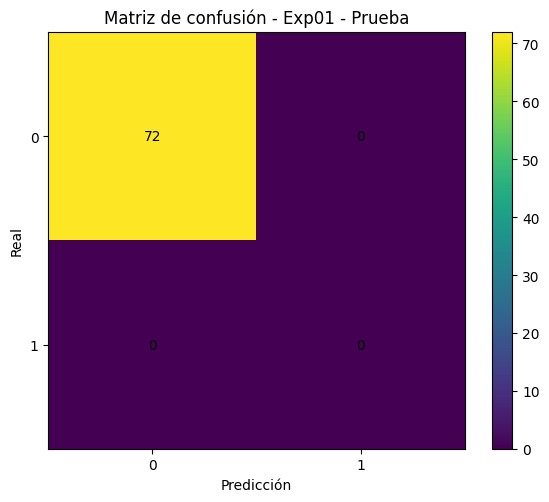


Gráfico generado: predicciones/Exp01/matriz_confusion_Exp01.png


In [12]:
#==========================================================================================
# SCRIPT 61
# VISUALIZACIÓN DE RESULTADOS DE PRUEBA
#==========================================================================================

ARCHIVO_GRAFICO = None

if es_clasificacion(TIPO_PROBLEMA):
    y_real_test = df_test["Real"].astype(int).to_numpy()
    y_pred_test = df_test["Prediccion"].astype(int).to_numpy()

    cm_test = confusion_matrix(
        y_real_test,
        y_pred_test,
        labels=[0, 1]
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    imagen = ax.imshow(cm_test)
    ax.set_title(f"Matriz de confusión - {EXPERIMENTO} - Prueba")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_test[i, j]), ha="center", va="center")

    fig.colorbar(imagen, ax=ax)
    fig.tight_layout()

    ARCHIVO_GRAFICO = os.path.join(
        CARPETA_PREDICCIONES,
        f"matriz_confusion_{EXPERIMENTO}.png"
    )
    fig.savefig(ARCHIVO_GRAFICO, dpi=200, bbox_inches="tight")
    plt.show()

else:
    real = df_test["Real"].astype(float).to_numpy()
    pred = df_test["Prediccion"].astype(float).to_numpy()

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(real, pred, alpha=0.75)

    minimo = min(real.min(), pred.min())
    maximo = max(real.max(), pred.max())
    ax.plot([minimo, maximo], [minimo, maximo], linestyle="--")

    ax.set_title(f"Real vs Predicción - {EXPERIMENTO} - Prueba")
    ax.set_xlabel("Valor real")
    ax.set_ylabel("Predicción")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()

    ARCHIVO_GRAFICO = os.path.join(
        CARPETA_PREDICCIONES,
        f"real_vs_pred_{EXPERIMENTO}.png"
    )
    fig.savefig(ARCHIVO_GRAFICO, dpi=200, bbox_inches="tight")
    plt.show()

print()
print("Gráfico generado:", ARCHIVO_GRAFICO)


## **M9. Consolidación y Exportación de Resultados**


In [13]:
#==========================================================================================
# SCRIPT 62
# CONSOLIDACIÓN DE METADATA DE C15
#==========================================================================================

metadata_prediccion = pd.DataFrame({
    "Parametro": [
        "Experimento",
        "Dominio",
        "Tipo Problema",
        "Variable Objetivo",
        "Variable Objetivo Cientifico",
        "Modelo",
        "Metodo Transformacion",
        "Scaler X",
        "Transformacion Objetivo",
        "Scaler y",
        "Ventana",
        "Horizonte",
        "Variables Predictoras",
        "Variables Modelo",
        "Registros Procesados",
        "Predicciones Generadas",
        "Muestras Train",
        "Muestras Validacion",
        "Muestras Prueba",
        "Estado C14",
        "Estado C15",
        "Estados Coinciden",
        "Diferencia Max Tensor",
        "Estrategia Evaluacion",
        "Fecha Ejecucion",
        "Archivo Predicciones",
        "Archivo Predicciones Prueba",
        "Archivo Metricas"
    ],
    "Valor": [
        EXPERIMENTO,
        DOMINIO,
        TIPO_PROBLEMA,
        VARIABLE_OBJETIVO,
        VARIABLE_OBJETIVO_CIENTIFICO,
        NOMBRE_MODELO,
        METODO_TRANSFORMACION,
        ARCHIVO_SCALER_X,
        TRANSFORMACION_OBJETIVO,
        ARCHIVO_SCALER_Y if ARCHIVO_SCALER_Y else "No aplica",
        VENTANA,
        HORIZONTE,
        NUM_VARIABLES,
        ";".join(VARIABLES_MODELO),
        len(X_raw),
        len(resultados),
        int((resultados["Particion"] == "Train").sum()),
        int((resultados["Particion"] == "Validacion").sum()),
        int((resultados["Particion"] == "Prueba").sum()),
        ESTADO_C14,
        ESTADO_C15,
        ESTADOS_COINCIDEN,
        DIFERENCIA_MAX_TENSOR,
        "Reproducción independiente de C14 usando tensor_X_raw + scalers publicados",
        pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
        "predicciones.csv",
        "predicciones_prueba.csv",
        "metricas_particiones.csv"
    ]
})

print()
print("=" * 90)
print("METADATA DE LA EVALUACIÓN")
print("=" * 90)
print()
display(metadata_prediccion)



METADATA DE LA EVALUACIÓN



,Parametro,Valor
0,Experimento,Exp01
1,Dominio,Gestión Hídrica
2,Tipo Problema,Clasificación
3,Variable Objetivo,nivel_de_riesgo
4,Variable Objetivo Cientifico,irca
5,Modelo,modelo_Exp01_nivel_de_riesgo.keras
6,Metodo Transformacion,RobustScaler
7,Scaler X,scaler.pkl
8,Transformacion Objetivo,No aplica
9,Scaler y,No aplica


In [14]:
#==========================================================================================
# SCRIPT 63
# EXPORTACIÓN DE RESULTADOS
#==========================================================================================

RUTA_PREDICCIONES_CSV = os.path.join(
    CARPETA_PREDICCIONES,
    "predicciones.csv"
)
RUTA_PREDICCIONES_XLSX = os.path.join(
    CARPETA_PREDICCIONES,
    "predicciones.xlsx"
)
RUTA_PREDICCIONES_TEST_CSV = os.path.join(
    CARPETA_PREDICCIONES,
    "predicciones_prueba.csv"
)
RUTA_METRICAS_CSV = os.path.join(
    CARPETA_PREDICCIONES,
    "metricas_particiones.csv"
)
RUTA_METRICAS_XLSX = os.path.join(
    CARPETA_PREDICCIONES,
    "metricas_particiones.xlsx"
)
RUTA_METRICAS_NODO_CSV = os.path.join(
    CARPETA_PREDICCIONES,
    "metricas_por_nodo.csv"
)
RUTA_BASELINES_CSV = os.path.join(
    CARPETA_PREDICCIONES,
    "baselines.csv"
)
RUTA_METADATA_CSV = os.path.join(
    CARPETA_PREDICCIONES,
    "metadata_prediccion.csv"
)
RUTA_METADATA_XLSX = os.path.join(
    CARPETA_PREDICCIONES,
    "metadata_prediccion.xlsx"
)
RUTA_VALIDACION_CSV = os.path.join(
    CARPETA_PREDICCIONES,
    "validacion_integridad.csv"
)

resultados.to_csv(
    RUTA_PREDICCIONES_CSV,
    index=False,
    encoding="utf-8-sig"
)
resultados.to_excel(
    RUTA_PREDICCIONES_XLSX,
    index=False
)

df_test.to_csv(
    RUTA_PREDICCIONES_TEST_CSV,
    index=False,
    encoding="utf-8-sig"
)

metricas_particiones.to_csv(
    RUTA_METRICAS_CSV,
    index=False,
    encoding="utf-8-sig"
)
metricas_particiones.to_excel(
    RUTA_METRICAS_XLSX,
    index=False
)

metricas_por_nodo.to_csv(
    RUTA_METRICAS_NODO_CSV,
    index=False,
    encoding="utf-8-sig"
)

if len(baselines_df) > 0:
    baselines_df.to_csv(
        RUTA_BASELINES_CSV,
        index=False,
        encoding="utf-8-sig"
    )

metadata_prediccion.to_csv(
    RUTA_METADATA_CSV,
    index=False,
    encoding="utf-8-sig"
)
metadata_prediccion.to_excel(
    RUTA_METADATA_XLSX,
    index=False
)

validacion_integridad.to_csv(
    RUTA_VALIDACION_CSV,
    index=False,
    encoding="utf-8-sig"
)

print()
print("=" * 90)
print("RESULTADOS EXPORTADOS")
print("=" * 90)
print()
for ruta in [
    RUTA_PREDICCIONES_CSV,
    RUTA_PREDICCIONES_XLSX,
    RUTA_PREDICCIONES_TEST_CSV,
    RUTA_METRICAS_CSV,
    RUTA_METRICAS_XLSX,
    RUTA_METRICAS_NODO_CSV,
    RUTA_METADATA_CSV,
    RUTA_METADATA_XLSX,
    RUTA_VALIDACION_CSV
]:
    print("-", ruta)

if len(baselines_df) > 0:
    print("-", RUTA_BASELINES_CSV)



RESULTADOS EXPORTADOS

- predicciones/Exp01/predicciones.csv
- predicciones/Exp01/predicciones.xlsx
- predicciones/Exp01/predicciones_prueba.csv
- predicciones/Exp01/metricas_particiones.csv
- predicciones/Exp01/metricas_particiones.xlsx
- predicciones/Exp01/metricas_por_nodo.csv
- predicciones/Exp01/metadata_prediccion.csv
- predicciones/Exp01/metadata_prediccion.xlsx
- predicciones/Exp01/validacion_integridad.csv


## **M10. Manifiesto y Validación Final de Artefactos**


In [15]:
#==========================================================================================
# SCRIPT 64
# MANIFIESTO DE ARTEFACTOS C15
#==========================================================================================

archivos_salida = [
    RUTA_PREDICCIONES_CSV,
    RUTA_PREDICCIONES_XLSX,
    RUTA_PREDICCIONES_TEST_CSV,
    RUTA_METRICAS_CSV,
    RUTA_METRICAS_XLSX,
    RUTA_METRICAS_NODO_CSV,
    RUTA_METADATA_CSV,
    RUTA_METADATA_XLSX,
    RUTA_VALIDACION_CSV,
    ARCHIVO_GRAFICO
]

if len(baselines_df) > 0:
    archivos_salida.append(RUTA_BASELINES_CSV)

archivos_salida = [
    ruta for ruta in archivos_salida
    if ruta is not None
]

manifiesto = pd.DataFrame({
    "Archivo": archivos_salida,
    "Existe": [os.path.exists(ruta) for ruta in archivos_salida],
    "Bytes": [os.path.getsize(ruta) if os.path.exists(ruta) else 0 for ruta in archivos_salida],
    "SHA256": [sha256_archivo(ruta) if os.path.exists(ruta) else "" for ruta in archivos_salida]
})

RUTA_MANIFIESTO = os.path.join(
    CARPETA_PREDICCIONES,
    f"manifiesto_artefactos_C15_{EXPERIMENTO}.csv"
)

manifiesto.to_csv(
    RUTA_MANIFIESTO,
    index=False,
    encoding="utf-8-sig"
)

print()
print("=" * 90)
print("MANIFIESTO DE ARTEFACTOS")
print("=" * 90)
print()
display(manifiesto)



MANIFIESTO DE ARTEFACTOS



,Archivo,Existe,Bytes,SHA256
0,predicciones/Exp01/predicciones.csv,True,43389,50f79adffb022b7791bfea28f05a0700acc4a6f2574813...
1,predicciones/Exp01/predicciones.xlsx,True,33329,49f6824d8b900f8f6b9161c33db616e9b5e1755b301136...
2,predicciones/Exp01/predicciones_prueba.csv,True,6645,3b069d515e1eca0d1c8d2040769b7aeec70f4dd34c7cf0...
3,predicciones/Exp01/metricas_particiones.csv,True,474,4da65cc59f957b54b7f21153b85fa1424b46c9030d8438...
4,predicciones/Exp01/metricas_particiones.xlsx,True,5358,648e744178e4d42261933c4cc82d011de2bf4a7bf0c9c9...
5,predicciones/Exp01/metricas_por_nodo.csv,True,312,43aea8e8b4986cbfb2e9897f6ded39958d365ed7e17e8b...
6,predicciones/Exp01/metadata_prediccion.csv,True,1075,12e04fe22225151ce866e0d6b831bcdb9b04b55be697bd...
7,predicciones/Exp01/metadata_prediccion.xlsx,True,5825,bf248ef39a3c974effbd1e93f7203035d8bbadec64e903...
8,predicciones/Exp01/validacion_integridad.csv,True,422,dcb119985f18bd09770bed64acc68e072cbe45a90570d6...
9,predicciones/Exp01/matriz_confusion_Exp01.png,True,39018,3214662981543972867d8f32a8a218af141a7e1e23570e...


In [16]:
#==========================================================================================
# SCRIPT 65
# VALIDACIÓN FINAL DE C15
#==========================================================================================

controles_finales = {
    "Integridad_artefactos_entrada": bool(all(controles_integridad.values())),
    "Predicciones_completas": len(resultados) == len(X_raw),
    "Sin_NaN_predicciones": resultados["Prediccion"].notna().all(),
    "Prueba_presente": (resultados["Particion"] == "Prueba").any(),
    "Metadata_exportada": os.path.exists(RUTA_METADATA_CSV),
    "Predicciones_exportadas": os.path.exists(RUTA_PREDICCIONES_CSV),
    "Metricas_exportadas": os.path.exists(RUTA_METRICAS_CSV),
    "Manifiesto_exportado": os.path.exists(RUTA_MANIFIESTO),
    "Scaler_reproduce_tensor_C14": DIFERENCIA_MAX_TENSOR <= TOLERANCIA_TENSOR
}

if es_regresion(TIPO_PROBLEMA):
    controles_finales["Scaler_y_aplicado"] = scaler_y is not None

VALIDACION_FINAL_C15 = all(controles_finales.values())

print()
print("=" * 90)
print("VALIDACIÓN FINAL C15")
print("=" * 90)
print()
for control, valor in controles_finales.items():
    print(f"- {control:<40}: {valor}")
print()
print(f"Estado C14            : {ESTADO_C14}")
print(f"Estado reproducido C15: {ESTADO_C15}")
print(f"Estados coinciden     : {ESTADOS_COINCIDEN}")
print()

if not VALIDACION_FINAL_C15:
    raise ValueError(
        "C15 detectó inconsistencias en la evaluación o exportación."
    )

print("Resultado : C15 COMPLETADO Y VALIDADO")



VALIDACIÓN FINAL C15

- Integridad_artefactos_entrada           : True
- Predicciones_completas                  : True
- Sin_NaN_predicciones                    : True
- Prueba_presente                         : True
- Metadata_exportada                      : True
- Predicciones_exportadas                 : True
- Metricas_exportadas                     : True
- Manifiesto_exportado                    : True
- Scaler_reproduce_tensor_C14             : True

Estado C14            : EVALUACION LIMITADA - TEST CON UNA SOLA CLASE
Estado reproducido C15: EVALUACION LIMITADA - TEST CON UNA SOLA CLASE
Estados coinciden     : True

Resultado : C15 COMPLETADO Y VALIDADO


## **M11. Resumen Final del Framework**


In [17]:
#==========================================================================================
# SCRIPT 66
# RESUMEN FINAL DEL FRAMEWORK DE EVALUACIÓN
#==========================================================================================

RUTA_ZIP = shutil.make_archive(
    f"C15_{EXPERIMENTO}",
    "zip",
    CARPETA_PREDICCIONES
)

print()
print("=" * 90)
print("FRAMEWORK V7 - C15 EVALUACIÓN FINALIZADA")
print("=" * 90)
print()
print(f"Experimento              : {EXPERIMENTO}")
print(f"Dominio                  : {DOMINIO}")
print(f"Tipo de problema         : {TIPO_PROBLEMA}")
print(f"Objetivo modelo          : {VARIABLE_OBJETIVO}")
print(f"Objetivo científico      : {VARIABLE_OBJETIVO_CIENTIFICO}")
print(f"Modelo utilizado         : {NOMBRE_MODELO}")
print(f"Ventana / Horizonte      : {VENTANA} / {HORIZONTE}")
print(f"Predictoras              : {NUM_VARIABLES}")
print(f"Secuencias evaluadas     : {len(resultados)}")
print(f"Train / Valid / Prueba   : "
      f"{(resultados['Particion']=='Train').sum()} / "
      f"{(resultados['Particion']=='Validacion').sum()} / "
      f"{(resultados['Particion']=='Prueba').sum()}")
print(f"Transformación X         : {METODO_TRANSFORMACION}")
print(f"Transformación y         : {TRANSFORMACION_OBJETIVO}")
print(f"Estado C14               : {ESTADO_C14}")
print(f"Estado C15               : {ESTADO_C15}")
print(f"Estados coinciden        : {ESTADOS_COINCIDEN}")
print()
print("C15 NO ajustó nuevamente el modelo ni los scalers.")
print("C15 reprodujo el preprocesamiento de C14 y evaluó el modelo publicado.")
print()
print("Artefactos para C16:")
print(f"- {RUTA_PREDICCIONES_CSV}")
print(f"- {RUTA_METADATA_CSV}")
print(f"- {RUTA_METRICAS_CSV}")
print(f"- {RUTA_PREDICCIONES_TEST_CSV}")
print()
print(f"Paquete ZIP              : {RUTA_ZIP}")
print()
print("Ruta GitHub sugerida     : DATA/EVALUACIONES/" + EXPERIMENTO + "/")
print()
print("Proceso completado correctamente.")



FRAMEWORK V7 - C15 EVALUACIÓN FINALIZADA

Experimento              : Exp01
Dominio                  : Gestión Hídrica
Tipo de problema         : Clasificación
Objetivo modelo          : nivel_de_riesgo
Objetivo científico      : irca
Modelo utilizado         : modelo_Exp01_nivel_de_riesgo.keras
Ventana / Horizonte      : 12 / 1
Predictoras              : 8
Secuencias evaluadas     : 480
Train / Valid / Prueba   : 336 / 72 / 72
Transformación X         : RobustScaler
Transformación y         : No aplica
Estado C14               : EVALUACION LIMITADA - TEST CON UNA SOLA CLASE
Estado C15               : EVALUACION LIMITADA - TEST CON UNA SOLA CLASE
Estados coinciden        : True

C15 NO ajustó nuevamente el modelo ni los scalers.
C15 reprodujo el preprocesamiento de C14 y evaluó el modelo publicado.

Artefactos para C16:
- predicciones/Exp01/predicciones.csv
- predicciones/Exp01/metadata_prediccion.csv
- predicciones/Exp01/metricas_particiones.csv
- predicciones/Exp01/predicciones_prueb